In [1]:
import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torch.utils.data import random_split

In [2]:
compound_with_desc = pd.read_csv('comound_with_desc.csv')
descriptor = pd.read_csv('descriptor.csv')
descriptor.head(13)

,Unnamed: 0,descriptor,linear_abs_pearson,linear_pearson,nonlinear_mutual_info
0,0,MolLogP,0.827918,-0.827918,0.792878
1,1,PEOE_VSA6,0.704852,-0.704852,0.433297
2,2,MolMR,0.699756,-0.699756,0.500652
3,3,LabuteASA,0.655502,-0.655502,0.469273
4,4,Chi0v,0.654884,-0.654884,0.520071
5,5,MolWt,0.640189,-0.640189,0.467775
6,6,HeavyAtomMolWt,0.639511,-0.639511,0.500044
7,7,ExactMolWt,0.639112,-0.639112,0.458112
8,8,Chi1v,0.635888,-0.635888,0.541120
9,9,FpDensityMorgan1,0.600940,0.600940,0.249728


In [3]:
x_data = compound_with_desc[['MolLogP', 'PEOE_VSA6', 'MolMR', 'LabuteASA', 'Chi0v', 'MolWt', 'Chi1v', 'FpDensityMorgan1', 'BCUT2D_LOGPHI', 'BertzCT']]
x_data = x_data.to_numpy()
x_data

array([[ -3.10802   ,  30.33183534, 102.2816    , ...,   0.8125    ,
          2.28493545, 724.15524755],
       [  2.84032   ,  18.19910121,  57.8402    , ...,   1.2       ,
          2.12018674, 445.90036643],
       [  2.878     ,  17.22222917,  48.486     , ...,   1.27272727,
          2.04514053, 166.47733176],
       ...,
       [  2.99      ,  18.305462  ,  63.76      , ...,   1.25      ,
          2.59103113, 124.9737366 ],
       [  2.0524    ,  27.19203322,  25.129     , ...,   1.4       ,
          1.9339847 ,  14.        ],
       [  5.6015    ,  46.40375956,  78.0115    , ...,   1.10526316,
          2.51889752, 507.08500244]], shape=(1128, 10))

In [4]:
y_data = compound_with_desc['measured log solubility in mols per litre']
y_data = y_data.to_numpy()
y_data

y_mean = y_data.mean()
y_std = y_data.std()
new_y_data = (y_data - y_mean) / y_std
new_y_data



array([ 1.08808837, -0.11925395,  0.47248695, ..., -0.01951697,
       -0.0619887 , -0.70240506], shape=(1128,))

In [5]:
class ESOL_Data(Dataset):
    def __init__(self, train_x, train_y):
        self.train_x = torch.tensor(train_x, dtype=torch.float32, device="cuda")
        self.train_y = torch.tensor(train_y, dtype=torch.float32, device="cuda")
        self.len = self.train_x.shape[0]

    def __getitem__(self, index):
        return  self.train_x[index], self.train_y[index]
    
    def __len__(self):
        return self.len

es_data = ESOL_Data(x_data,new_y_data)
train_size = int(es_data.len *0.8)
test_size = es_data.len - train_size

train_data, test_data = random_split(es_data, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [6]:
class Esol_Model(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = torch.nn.Linear(10, 5, bias=True)
        self.linear2 = torch.nn.Linear(5, 2, bias=True)
        self.linear3 = torch.nn.Linear(2, 1, bias=True)
        self.relu = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(0.3)

    def forward(self, x):
        x = self.linear1(x)
        x = self.dropout(x)
        x = self.linear2(x)
        x = self.dropout(x)
        return self.linear3(x)
    
es_model = Esol_Model().to('cuda')
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(es_model.parameters(),lr=3e-4,weight_decay=1e-4)

In [7]:
for epoch in range(1,201):
    for i,data in enumerate(train_loader, 1):
        x, y = data
        x = x.to('cuda')
        y = y.to('cuda')
        y_hat = es_model(x)
        loss = criterion(y_hat, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"epoch:{epoch};i:{i};loss:{loss.item()}")
    if(loss<2 and epoch > 50):
        break

c:\Anaconda\envs\pytorch\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Anaconda\envs\pytorch\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([6])) that is different to the input size (torch.Size([6, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


epoch:1;i:15;loss:840.2861328125
epoch:2;i:15;loss:431.2135925292969
epoch:3;i:15;loss:2043.7977294921875
epoch:4;i:15;loss:981.0388793945312
epoch:5;i:15;loss:796.3726806640625
epoch:6;i:15;loss:2588.736083984375
epoch:7;i:15;loss:509.9244689941406
epoch:8;i:15;loss:655.640380859375
epoch:9;i:15;loss:463.9123840332031
epoch:10;i:15;loss:1563.9127197265625
epoch:11;i:15;loss:937.8780517578125
epoch:12;i:15;loss:231.7557830810547
epoch:13;i:15;loss:831.6239624023438
epoch:14;i:15;loss:619.6752319335938
epoch:15;i:15;loss:74.64734649658203
epoch:16;i:15;loss:848.5875854492188
epoch:17;i:15;loss:221.7234649658203
epoch:18;i:15;loss:129.44158935546875
epoch:19;i:15;loss:60.28395462036133
epoch:20;i:15;loss:484.1435546875
epoch:21;i:15;loss:712.357666015625
epoch:22;i:15;loss:527.4912109375
epoch:23;i:15;loss:167.9188690185547
epoch:24;i:15;loss:542.9400024414062
epoch:25;i:15;loss:638.3117065429688
epoch:26;i:15;loss:289.85546875
epoch:27;i:15;loss:178.3404083251953
epoch:28;i:15;loss:154.

In [8]:
def h(num, mean=y_mean, std=y_std):
    return num * std + mean

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    preds = []
    targets = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to('cuda').float()
            y = y.to('cuda').float().unsqueeze(1)

            y_hat = model(x)

            preds.append(y_hat.cpu())
            targets.append(y.cpu())

    preds = torch.cat(preds)
    targets = torch.cat(targets)

    rmse = torch.sqrt(torch.mean((h(preds) - h(targets)) ** 2))
    mae  = torch.mean(torch.abs(h(preds) - h(targets)))

    return rmse.item(), mae.item(), h(preds), h(targets)

train_rmse, train_mae, train_preds, train_targets = evaluate(es_model, train_loader)
test_rmse, test_mae, test_preds, test_targets = evaluate(es_model, test_loader)

train_preds_np = train_preds.detach().cpu().numpy().flatten()
train_targes_np = train_targets.detach().cpu().numpy().flatten()

test_preds_np = test_preds.detach().cpu().numpy().flatten()
test_targes_np = test_targets.detach().cpu().numpy().flatten()

print(f"train rmse:{train_rmse}")
print(f"train mae:{train_mae}")
print(f"test rmse:{test_rmse}")
print(f"test mae:{test_mae}")

train rmse:2.6071767807006836
train mae:1.931416392326355
test rmse:2.6785123348236084
test mae:1.9979559183120728


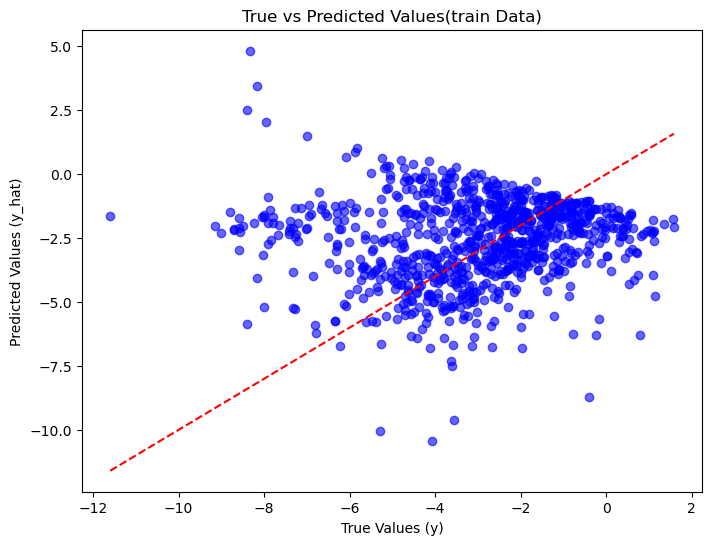

In [9]:
import matplotlib.pyplot as plt

# 画真实值 vs 预测值散点图
plt.figure(figsize=(8, 6))
plt.scatter(train_targes_np, train_preds_np, color='blue', alpha=0.6)

# 添加对角线（完美预测的线）
plt.plot([min(train_targes_np), max(train_targes_np)], [min(train_targes_np), max(train_targes_np)], color='red', linestyle='--')

# 设置标题和标签
plt.title('True vs Predicted Values(train Data)')
plt.xlabel('True Values (y)')
plt.ylabel('Predicted Values (y_hat)')

# 显示图像
plt.show()

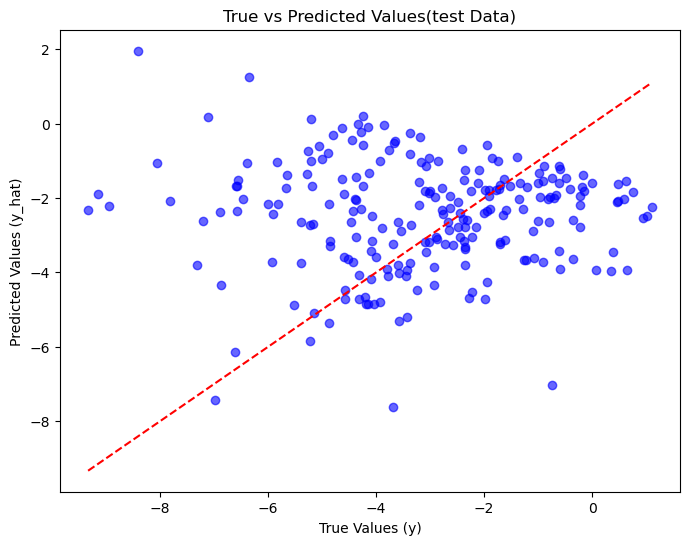

In [10]:
# 画真实值 vs 预测值散点图
plt.figure(figsize=(8, 6))
plt.scatter(test_targes_np, test_preds_np, color='blue', alpha=0.6)

# 添加对角线（完美预测的线）
plt.plot([min(test_targes_np), max(test_targes_np)], [min(test_targes_np), max(test_targes_np)], color='red', linestyle='--')

# 设置标题和标签
plt.title('True vs Predicted Values(test Data)')
plt.xlabel('True Values (y)')
plt.ylabel('Predicted Values (y_hat)')

# 显示图像
plt.show()